# Notebook 0 - Input data preparation

<hr>
This key module helps the user prepare all the input data (currently for module 1)

Prepared by Dario Spiller, Geospatial Unit at the Land and Water Division, FAO HQ
<hr>


In [69]:
'''import supporting libraries'''
# import pyaez
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
try:
    from osgeo import gdal
except:
    import gdal
import sys
import geopandas as gpd
import cavapy
import xarray as xr
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.features import rasterize
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling

os.environ['PROJ_LIB'] = '/opt/conda/envs/pyAEZ/share/proj'
gdal.UseExceptions()

In [70]:
# Set the working directory
work_dir = r'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code'  # Please change this to your working directory
os.chdir(work_dir)
sys.path.append(work_dir)
os.getcwd()


'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code'

In [76]:
from module0 import pre_proc_utilities

# Input data from the user

In [72]:
country_name = 'Togo'
years_list = [2000]

# Loading the reference UN shapefile (level 1)

In [73]:
country_name = country_name.lower()
AOI = pre_proc_utilities.get_UN_country(country_name, thr=3, return_gdf=False)
AOI

The country "Togo" was selected from the UN  database.


,romnam,iso3cd,maplab,geometry
0,Togo,TGO,TOGO,"POLYGON ((1.59914 6.90552, 1.59960 6.90559, 1...."


# Loading climate data 

In [74]:
country_name_cava = 'Togo'
rcp = "rcp26"
gcm = "MOHC" # [MOHC, NCC, MPI]
rcm = 'REMO' # [ICTP, REMO] 

historical = True
years_up_to = np.max([np.max(years_list)+1, 2007])   
years_obs = range(1980,np.min([np.max(years_list)+1,2019]))

if np.max(years_list) < 2007:
    # For historical data bias correction is not needed
    bias_correction = False
else:
    bias_correction = True
    
CAVA_climate_data = cavapy.get_climate_data(country=country_name_cava, 
                                             cordex_domain="AFR-22", 
                                             buffer=1,
                                             rcp=rcp, 
                                             gcm=gcm, 
                                             rcm=rcm, 
                                             num_processes=10,
                                             years_up_to=years_up_to, 
                                             obs=True, 
                                             bias_correction=bias_correction, 
                                             historical=historical, 
                                             years_obs=years_obs)


print('CAVA data fully retrieved!')
ds = CAVA_climate_data

2025-07-07 13:14:31,659 | climate.URL-validation-observations | 706740:133830947067712 [INFO]: https://hub.ipcc.ifca.es/thredds/dodsC/fao/observations/ERA5/0.25/ERA5_025.ncml
2025-07-07 13:14:34,771 | climate.tasmax-observations | 1596116:133827127150144 [INFO]: Establishing connection to ERA5 data for tasmax(t2mx)
2025-07-07 13:14:34,786 | climate.tasmin-observations | 1596115:133827127150144 [INFO]: Establishing connection to ERA5 data for tasmin(t2mn)
2025-07-07 13:14:34,764 | climate.pr-observations | 1596113:133827127150144 [INFO]: Establishing connection to ERA5 data for pr(tp)
2025-07-07 13:14:34,780 | climate.hurs-observations | 1596114:133827127150144 [INFO]: Establishing connection to ERA5 data for hurs(hurs)
2025-07-07 13:14:34,765 | climate.rsds-observations | 1596112:133827127150144 [INFO]: Establishing connection to ERA5 data for rsds(ssrd)
2025-07-07 13:14:34,765 | climate.sfcWind-observations | 1596111:133827127150144 [INFO]: Establishing connection to ERA5 data for sfc

CAVA data fully retrieved!


## Exporting CAVA data

In [75]:
times_cava = ds['tasmax']['time'].values
red_times_idx = [i for i,t in enumerate(times_cava) if str(years_list[0]) in str(t)]
times_cava[red_times_idx]

array(['2000-01-01T00:00:00.000000000', '2000-01-02T00:00:00.000000000',
       '2000-01-03T00:00:00.000000000', '2000-01-04T00:00:00.000000000',
       '2000-01-05T00:00:00.000000000', '2000-01-06T00:00:00.000000000',
       '2000-01-07T00:00:00.000000000', '2000-01-08T00:00:00.000000000',
       '2000-01-09T00:00:00.000000000', '2000-01-10T00:00:00.000000000',
       '2000-01-11T00:00:00.000000000', '2000-01-12T00:00:00.000000000',
       '2000-01-13T00:00:00.000000000', '2000-01-14T00:00:00.000000000',
       '2000-01-15T00:00:00.000000000', '2000-01-16T00:00:00.000000000',
       '2000-01-17T00:00:00.000000000', '2000-01-18T00:00:00.000000000',
       '2000-01-19T00:00:00.000000000', '2000-01-20T00:00:00.000000000',
       '2000-01-21T00:00:00.000000000', '2000-01-22T00:00:00.000000000',
       '2000-01-23T00:00:00.000000000', '2000-01-24T00:00:00.000000000',
       '2000-01-25T00:00:00.000000000', '2000-01-26T00:00:00.000000000',
       '2000-01-27T00:00:00.000000000', '2000-01-28

In [64]:
output_folder = rf'./data_input/CAVA_data/'
os.makedirs(output_folder, exist_ok=True)

np.save(os.path.join(output_folder, "time_array.npy"), times_cava[red_times_idx])

for var in ds.keys():
    print(f'Exporting {var}...')
    data = ds[var].values
    rearranged_data = np.moveaxis(data, 0, -1)
    np.save(os.path.join(output_folder, f"{var}.npy"), rearranged_data[:,:,red_times_idx])

/home/jovyan/conda_envs/pyaez_cava/lib/python3.12/site-packages/numpy/lib/format.py:382: UserWarning: metadata on a dtype is not saved to an npy/npz. Use another format (such as pickle) to store it.
  d['descr'] = dtype_to_descr(array.dtype)


Exporting pr...
Exporting tasmax...
Exporting tasmin...
Exporting hurs...
Exporting sfcWind...
Exporting rsds...


In [33]:
# Example: Load a variable named 'sfcWind'
loaded_data = np.load('./data_input/CAVA_data/sfcWind.npy')
loaded_data.shape

(29, 16, 7305)

In [65]:
loaded_data = np.load('./data_input/CAVA_data/time_array.npy')
loaded_data

array(['1999-01-01T00:00:00.000000000', '1999-01-02T00:00:00.000000000',
       '1999-01-03T00:00:00.000000000', '1999-01-04T00:00:00.000000000',
       '1999-01-05T00:00:00.000000000', '1999-01-06T00:00:00.000000000',
       '1999-01-07T00:00:00.000000000', '1999-01-08T00:00:00.000000000',
       '1999-01-09T00:00:00.000000000', '1999-01-10T00:00:00.000000000',
       '1999-01-11T00:00:00.000000000', '1999-01-12T00:00:00.000000000',
       '1999-01-13T00:00:00.000000000', '1999-01-14T00:00:00.000000000',
       '1999-01-15T00:00:00.000000000', '1999-01-16T00:00:00.000000000',
       '1999-01-17T00:00:00.000000000', '1999-01-18T00:00:00.000000000',
       '1999-01-19T00:00:00.000000000', '1999-01-20T00:00:00.000000000',
       '1999-01-21T00:00:00.000000000', '1999-01-22T00:00:00.000000000',
       '1999-01-23T00:00:00.000000000', '1999-01-24T00:00:00.000000000',
       '1999-01-25T00:00:00.000000000', '1999-01-26T00:00:00.000000000',
       '1999-01-27T00:00:00.000000000', '1999-01-28

## Example plot with pcolormesh

{'long_name': 'daily maximum temperature', 'units': '°C', '_ChunkSizes': array([30, 70, 70], dtype=int32)}
Temperature data shape: (14245, 21, 8)
Latitude shape: (21,)
Longitude shape: (8,)


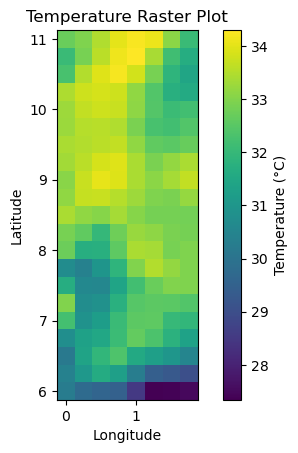

In [23]:
# Assuming the temperature data variable is called 'tasmax' (check the print output for the exact variable name)
# Extract the data as a numpy array
ds = ds['tasmax']
temp_data = ds.values

# Print the variable's attributes, which may include 'units', 'scale_factor', and 'add_offset'
print(ds.attrs)

# Extract the coordinates (lat, lon, and time if applicable)
latitudes = ds['latitude'].values
longitudes = ds['longitude'].values

# If time is also included:
if 'time' in ds:
    times = ds['time'].values

# Now you have the temperature data as a NumPy array and the corresponding coordinates
print("Temperature data shape:", temp_data.shape)
print("Latitude shape:", latitudes.shape)
print("Longitude shape:", longitudes.shape)

temp_data0 = temp_data[0,:,:]

# Plot with pcolormesh to handle correct lat/lon orientation
plt.figure()
plt.pcolormesh(longitudes, latitudes, temp_data0, shading='auto', cmap='viridis')
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Temperature Raster Plot')

# Set aspect ratio based on coordinate spacing
plt.gca().set_aspect('equal', adjustable='box') # Ensures square pixels in geographic space

plt.show()

# Optionally close the dataset
ds.close()

## Exporting as geotiff, with flipud operation required based on longitude sorting

In [14]:
# Extract the data as a numpy array
temp_data = ds.values

# Extract the coordinates (latitudes, longitudes)
latitudes = ds['latitude'].values
longitudes = ds['longitude'].values
times = ds.time.values

# Select a single time step (if time is a dimension)
temp_data0 = temp_data[0, :, :]  # Assuming [time, lat, lon]

# Check if latitudes are in ascending order, flip if needed (the numpy origin is in the top left corner!)
if latitudes[0] < latitudes[-1]:
    temp_data0 = np.flipud(temp_data0)
    
# No need to flip the data here, rasterio will handle it with the transform
# Define the geotransform (Affine transformation) based on the lat/lon bounds
transform = from_bounds(min(longitudes), min(latitudes), max(longitudes), max(latitudes), temp_data0.shape[1], temp_data0.shape[0])

# Define the CRS (Coordinate Reference System) - EPSG:4326 for WGS84
crs = CRS.from_epsg(4326)

# Output GeoTIFF file path
day_info = times[0].astype('M8[D]').astype(object).strftime('%Y-%m-%d')
output_tif = rf'./data_input/{country_name}_temperature_raster_{day_info}.tif'

# Write the data to a GeoTIFF
with rasterio.open(
    output_tif,
    'w',
    driver='GTiff',
    height=temp_data0.shape[0],
    width=temp_data0.shape[1],
    count=1,  # Single band
    dtype=temp_data0.dtype,
    crs=crs,
    transform=transform,
) as dst:
    dst.write(temp_data0, 1)  # Write the temperature data

print(f"GeoTIFF saved to {output_tif}")

# Optionally close the dataset
ds.close()


GeoTIFF saved to ./data_input/togo_temperature_raster_1980-01-01.tif


## Plotting the numpy array from the geotiff

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 8, 'height': 21, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.21875, 0.0, 0.0,
       0.0, -0.2380952388048172, 11.0), 'blockxsize': 8, 'blockysize': 21, 'tiled': False, 'interleave': 'band'}
BoundingBox(left=0.0, bottom=5.999999985098839, right=1.75, top=11.0)
EPSG:4326


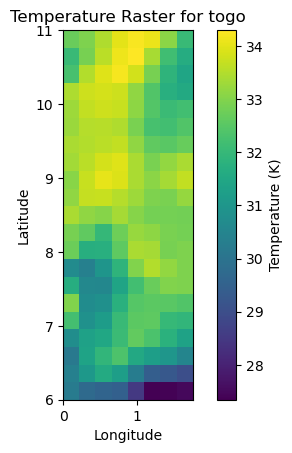

In [15]:
# Path to your saved GeoTIFF file
output_tif = rf'./data_input/{country_name}_temperature_raster_{day_info}.tif'

# Open the GeoTIFF file
with rasterio.open(output_tif) as src:
    # Read the first band of the raster
    temp_data0 = src.read(1)
    
    # Get the metadata to check georeferencing and dimensions
    print(src.profile)
    print(src.bounds)
    extent = src.bounds
    img_extent = [extent.left,extent.right,extent.bottom, extent.top]
    print(src.crs)
    
    # Plot the data
    plt.figure()
    img = plt.imshow(temp_data0, cmap='viridis', extent=img_extent, origin='upper')
    plt.colorbar(img, label='Temperature (K)')
    plt.title(f'Temperature Raster for {country_name}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()


## Masking the temperature data

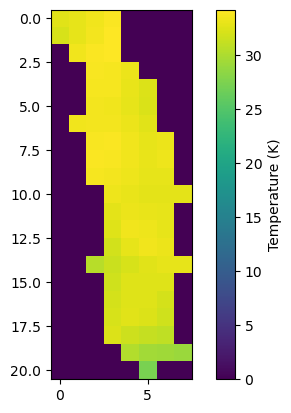

In [16]:
# Load the country shapefile (assuming unified_lao is your Lao GeoDataFrame)
AOI_geom = AOI.geometry

# Load the global temperature raster
temp_raster_path = rf'./data_input/{country_name}_temperature_raster_{day_info}.tif'

with rasterio.open(temp_raster_path) as temp_raster:
    
    # Clip the raster using the country geometry
    temperature_clipped, temperature_transform = mask(temp_raster, AOI_geom, crop=True)
    
    # Update the metadata to match the clipped raster
    temperature_meta = temp_raster.meta.copy()
    temperature_meta.update({
        "driver": "GTiff",
        "height": temperature_clipped.shape[1],
        "width": temperature_clipped.shape[2],
        "transform": temperature_transform
    })

# Optionally: Save the clipped raster to a new file
output_clipped_raster = rf'./data_input/{country_name}_clipped_temperature_raster_{day_info}.tif'
with rasterio.open(output_clipped_raster, 'w', **temperature_meta) as dst:
    dst.write(temperature_clipped)

# Mask the pixels with value -9999
masked_temperature = np.ma.masked_equal(temperature_clipped[0], -9999)

# Plot the temperature data, masking -9999
vmax, vmin = np.max(masked_temperature), np.min(masked_temperature)
plt.imshow(masked_temperature, vmax=vmax, vmin=vmin)
# Add a colorbar for reference
plt.colorbar(label='Temperature (K)');

## Defining the rasterized country AOI

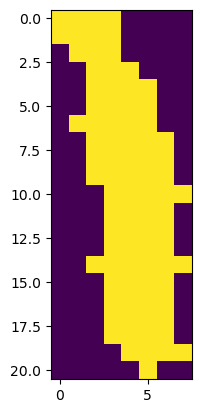

In [17]:
# Paths to input and output files
output_clipped_raster = rf'./data_input/{country_name}_clipped_temperature_raster_{day_info}.tif'
country_raster_output_path = rf'./data_input/{country_name}_rasterized.tif'

# Step 1: Open the clipped temperature raster to get its dimensions and transform
with rasterio.open(output_clipped_raster) as temp_raster:
    out_shape = (temp_raster.height, temp_raster.width)  # Use the clipped raster's shape
    out_transform = temp_raster.transform  # Get the transform to match the raster's extent
    ref_crs = temp_raster.crs  # Get the CRS for saving the output

    # Step 2: Rasterize the country geometry using the same dimensions and transform
    country_raster = rasterize(
        [(geom, 1) for geom in AOI_geom],  # Geometry to rasterize (value=1 for the country)
        out_shape=out_shape,
        transform=out_transform,
        fill=0,  # Values for areas outside the geometry (background = 0)
        dtype=np.uint8  # Data type of the output raster (can adjust as needed)
    )

# Step 3: Define metadata for the output raster file
country_raster_meta = {
    'driver': 'GTiff',
    'height': out_shape[0],
    'width': out_shape[1],
    'count': 1,  # Single band for this raster
    'dtype': np.uint8,  # Output data type (unsigned 8-bit)
    'crs': ref_crs,  # Coordinate reference system (same as input raster)
    'transform': out_transform  # Same georeferencing as input raster
}

# Step 4: Save the rasterized country geometry to a new file
with rasterio.open(country_raster_output_path, 'w', **country_raster_meta) as dest:
    dest.write(country_raster, 1)  # Write the rasterized data to the first band

# Step 5: Optionally, display the saved raster to verify
show(country_raster);


## Defining the DEM for the AOI at the original resolution

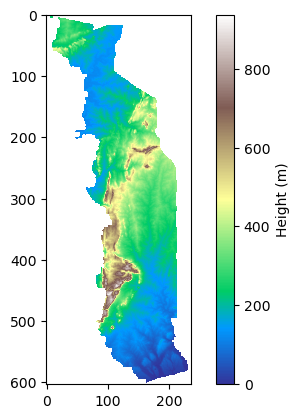

In [18]:
# Load the global temperature raster
DEM_raster_path = r'./data_input/DEM/altmed30s.tif'
with rasterio.open(DEM_raster_path) as DEM_raster:
    
    # Clip the raster using the country geometry
    DEM_clipped, DEM_transform = mask(DEM_raster, AOI_geom, crop=True)
    
    # Update the metadata to match the clipped raster
    DEM_meta = DEM_raster.meta.copy()
    DEM_meta.update({
        "driver": "GTiff",
        "height": DEM_clipped.shape[1],
        "width": DEM_clipped.shape[2],
        "transform": DEM_transform
    })

# Optionally: Save the clipped raster to a new file
DEM_clipped_raster = rf'./data_input/{country_name}_elevation_clipped.tif'
with rasterio.open(DEM_clipped_raster, 'w', **DEM_meta) as dst:
    dst.write(DEM_clipped)


# Mask the pixels with value -9999
masked_DEM = np.ma.masked_equal(DEM_clipped[0], -9999)

# Plot the temperature data, masking -9999
vmax, vmin = np.max(masked_DEM), np.min(masked_DEM)
plt.imshow(masked_DEM, vmax=vmax, vmin=vmin, cmap='terrain')
# Add a colorbar for reference
plt.colorbar(label='Height (m)');

## Defining the DEM for the AOI at the scaled resolution

Unique values: [19.0 22.0 28.0 44.0 65.0 73.0 77.0 100.0 105.0 116.0]


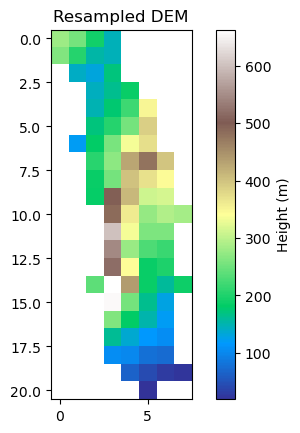

In [19]:
def process_raster(INPUT_raster_path, ref_raster_path, output_clipped_path, ref_geom, plot=False, 
                   title = [], colorbar_label = [], cmap = 'viridis', nodata = -9999):
    """
    Process a raster by clipping, resampling, and optionally plotting it.
    
    Parameters:
    - INPUT_raster_path: Path to the input raster file.
    - ref_raster_path: Path to the reference raster (e.g., temperature raster).
    - output_clipped_path: Path to save the final clipped raster.
    - ref_geom: Geometry to clip the raster.
    - plot: Boolean flag to plot the result (default: False).
    """
    
    # Load the reference raster (e.g., temperature raster) to get its resolution, extent, and CRS
    with rasterio.open(ref_raster_path) as ref_raster:
        ref_transform = ref_raster.transform
        ref_crs = ref_raster.crs
        ref_shape = ref_raster.shape  # Get the shape (height, width) of the reference raster
        ref_res = ref_raster.res      # Get the pixel resolution of the reference raster

    # Step 1: Load the DEM raster and clip it using the country geometry (bounding box)
    with rasterio.open(INPUT_raster_path) as INPUT_raster:
        raster_clipped, raster_transform = mask(INPUT_raster, ref_geom.envelope, crop=True)
        raster_nodata = INPUT_raster.nodata  # Get the NoData value from the original DEM
        raster_clipped = np.where(raster_clipped == raster_nodata, 0, raster_clipped)  # Replace NoData with 0

        # Step 2: Resample the DEM to match the resolution and extent of the reference raster
        raster_resampled = np.empty(ref_shape, raster_clipped.dtype)  # Create an empty array for resampling
        reproject(
            source=raster_clipped,
            destination=raster_resampled,
            src_transform=raster_transform,
            src_crs=INPUT_raster.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.med  # Bilinear interpolation for resampling
        )

        # Step 3: Update metadata to match the reference raster's characteristics
        ratser_meta = INPUT_raster.meta.copy()
        ratser_meta.update({
            "driver": "GTiff",
            "height": ref_shape[0],
            "width": ref_shape[1],
            "transform": ref_transform,
            'dtype': np.float32,  # Output data type (unsigned 8-bit)
            "crs": ref_crs,
            "nodata": nodata  # Specify the NoData value
        })

        # Step 4: Save the resampled DEM to a new file
        with rasterio.open(output_clipped_path, 'w', **ratser_meta) as dst:
            dst.write(raster_resampled, 1)  # Write the resampled DEM to disk

    # Step 5: Load the resampled DEM and clip it using the country geometry
    with rasterio.open(output_clipped_path) as resampled_raster:
        resampled_clipped, _ = mask(resampled_raster, AOI_geom, crop=True, nodata = -9999)
        ratser_meta = resampled_raster.meta.copy()
        resampled_clipped = resampled_clipped[0]  # Extract the first band (DEM data)

    # Step 6: Save the clipped DEM to a new file
    with rasterio.open(output_clipped_path, 'w', **ratser_meta) as dst:
        dst.write(resampled_clipped, 1)  # Write the clipped DEM

    # Step 7: Optionally, mask -9999 values and plot the final result
    masked_raster = np.ma.masked_equal(resampled_clipped, -9999)

    print('Unique values:', np.unique(masked_raster)[:10])
    
    if plot:
        vmax, vmin = np.max(masked_raster), np.min(masked_raster)
        plt.imshow(masked_raster, vmax=vmax, vmin=vmin, cmap=cmap)  # Use terrain colormap
        plt.colorbar(label=colorbar_label)
        plt.title(title)
        plt.show()

    return masked_raster
    
# Example usage:
elv = process_raster(INPUT_raster_path = './data_input/DEM/altmed30s.tif', 
                  ref_raster_path = f'./data_input/{country_name}_clipped_temperature_raster_{day_info}.tif',
                  output_clipped_path = f'./data_input/{country_name}_elevation_resampled_clipped.tif',
                  ref_geom = AOI_geom, plot=True, title = 'Resampled DEM', colorbar_label = 'Height (m)', cmap='terrain')


## Defining the LULC layer for the AOI at the scaled resolution

Unique values: [3.0 4.0 5.0 --]


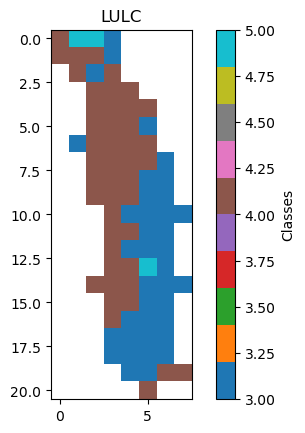

In [20]:
# Example usage:
lulc = process_raster(INPUT_raster_path = './data_input/LULC/soil_regime_CRUTS32_Hist_8110.tif', 
                  ref_raster_path = f'./data_input/{country_name}_clipped_temperature_raster_{day_info}.tif',
                  output_clipped_path = f'./data_input/{country_name}_lulc_resampled_clipped.tif',
                  ref_geom = AOI_geom, plot=True, title = 'LULC', colorbar_label = 'Classes', cmap='tab10')